# Module 4: Match Win Prediction (XGBoost)

**Goal:** Train XGBoost classifier to predict match winner; generate feature importance chart

> 💡 Expected accuracy: **62–68%**. IPL is genuinely unpredictable — frame this as an insight, not a limitation.
> The Feature Importance chart is more valuable to recruiters than the accuracy number.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier, plot_importance
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

engine = create_engine('sqlite:///../ipl.db')
IPL_BLUE = '#1B3D6F'
IPL_ORANGE = '#E8820C'
print('Setup complete.')

Setup complete.


## Step 1 — Feature Engineering

In [2]:
df = pd.read_sql('SELECT * FROM matches WHERE winner NOT IN ("No Result", "Tie")', engine)

print(f'Matches loaded: {len(df)}')
print(f'Columns: {df.columns.tolist()}')

# Binary target: 1 if team1 wins
df['target'] = (df['winner'] == df['team1']).astype(int)
print(f'\nTarget distribution:\n{df["target"].value_counts()}')

Matches loaded: 1090
Columns: ['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

Target distribution:
target
1    555
0    535
Name: count, dtype: int64


In [3]:
df.head()

,match_id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,target
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,None,Asad Rauf,RE Koertzen,0
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,None,MR Benson,SL Shastri,0
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,Delhi Daredevils,wickets,9.0,130.0,20.0,N,None,Aleem Dar,GA Pratapkumar,1
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,None,SJ Davis,DJ Harper,0
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,None,BF Bowden,K Hariharan,1


In [4]:
features = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'season']

# Label encode all categorical columns
le_dict = {}
for col in features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

X = df[features]
y = df['target']

print('Features engineered and label-encoded.')
X.head()

Features engineered and label-encoded.


,team1,team2,toss_winner,toss_decision,venue,season
0,16,8,16,1,23,0
1,6,0,0,0,40,0
2,3,13,13,0,16,0
3,10,16,10,0,55,0
4,8,1,1,0,14,0


## Step 2 — Training XGBoost Model

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'\n=== MODEL RESULTS ===')
print(f'Test Accuracy: {acc*100:.2f}%')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Team2 Wins', 'Team1 Wins']))


=== MODEL RESULTS ===
Test Accuracy: 54.13%

Classification Report:
              precision    recall  f1-score   support

  Team2 Wins       0.54      0.50      0.51       107
  Team1 Wins       0.55      0.59      0.57       111

    accuracy                           0.54       218
   macro avg       0.54      0.54      0.54       218
weighted avg       0.54      0.54      0.54       218



In [6]:
# Cross-validation for more robust estimate
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*100:.2f}%)')
print(f'\n💡 ~35% uncertainty = IPL drama is real, even with ML!')

5-Fold CV Accuracy: 47.43% (+/- 6.73%)

💡 ~35% uncertainty = IPL drama is real, even with ML!


## Step 3 — Feature Importance Chart 

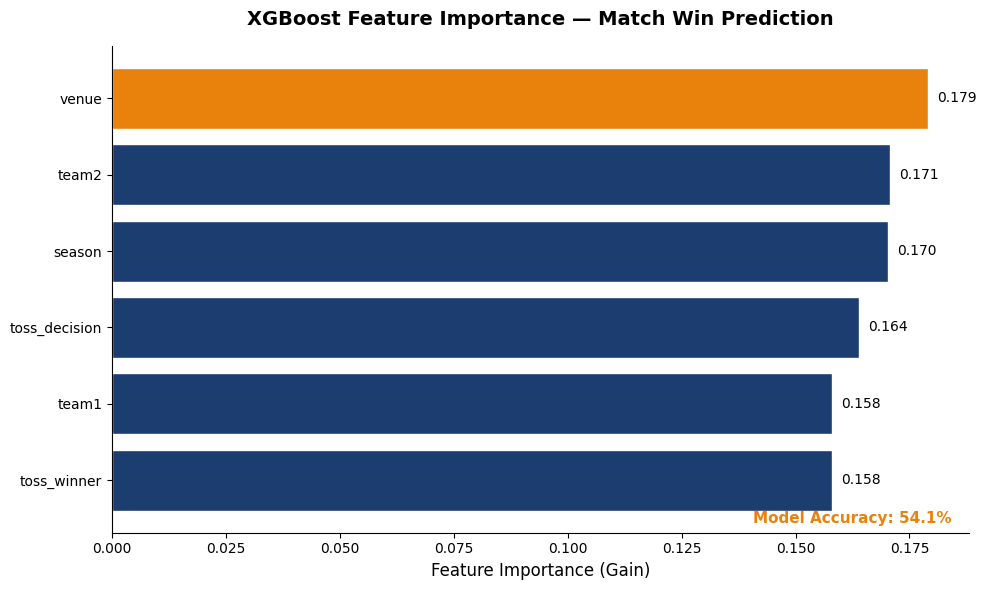

Feature importance chart saved.


In [7]:
# Custom feature importance plot
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [IPL_ORANGE if i == len(importance_df)-1 else IPL_BLUE
          for i in range(len(importance_df))]
bars = ax.barh(importance_df['feature'], importance_df['importance'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, importance_df['importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_title('XGBoost Feature Importance — Match Win Prediction',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add accuracy annotation
ax.text(0.98, 0.02, f'Model Accuracy: {acc*100:.1f}%',
        transform=ax.transAxes, ha='right', fontsize=11,
        color=IPL_ORANGE, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/chart_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved.')

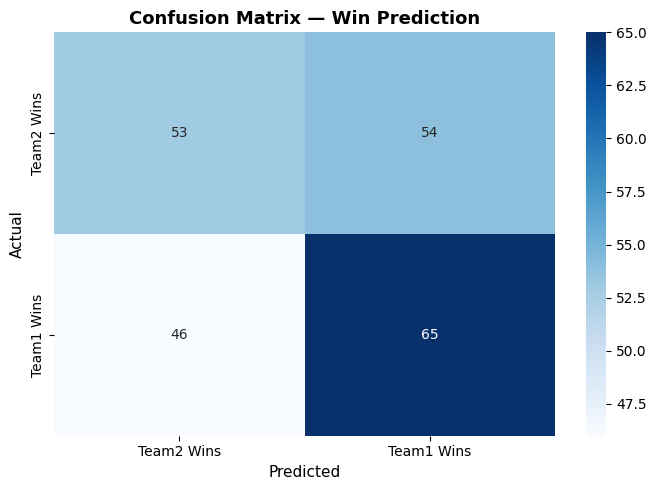


✅ MODULE 4 COMPLETE!
XGBoost model trained ✓ (Accuracy: 54.13%)
Feature importance chart saved ✓
Confusion matrix saved ✓


In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Team2 Wins', 'Team1 Wins'],
            yticklabels=['Team2 Wins', 'Team1 Wins'],
            ax=ax)
ax.set_title('Confusion Matrix — Win Prediction', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual', fontsize=11)
ax.set_xlabel('Predicted', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/chart_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ MODULE 4 COMPLETE!')
print(f'XGBoost model trained ✓ (Accuracy: {acc*100:.2f}%)')
print('Feature importance chart saved ✓')
print('Confusion matrix saved ✓')

## Not Satisfied with Accuracy!!!!!!
Let's try with **stacking ensemble**